# Methylation compartments vs gene expression (Fig 2I–L, S11A–F)

Part of the **[Fig. 2 chapter](fig2.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{indir}L1color.tsv'`  ·  _metadata: color_
- `f'{REF_ROOT}/hg38/gencode/v30/gencode.v30.annotation.gene.flat.tsv.gz'`  ·  _ref: gencode_
- `f'{pmddir}{ct}_10kb_hist.h5ad'`  ·  _PMD/methyl-compartment_
- `f'{outdir}{group_name}/bulkexpr_{study}.hdf'`  ·  _expression_
- `f'{outdir}{group_name}/design_{study}.hdf'`  ·  _other_
- `f'{outdir}flank_bed/{peak_ct}.split{split}.slop{ws}b.{w}b.{bw_ct}.CGN-Merge.hdf'`  ·  _other_
- `f'{outdir}flank_bed/tss_{pmd_ct}_3state.txt'`  ·  _PMD/methyl-compartment_
- `f'{indir}analysis/PMD/{pmd_file}.pmd.gene50.txt'`  ·  _PMD/methyl-compartment_
- `f'{indir}analysis/PMD/{pmd_file}.pmd.tss.txt'`  ·  _PMD/methyl-compartment_


In [1]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [2]:
import os
import time
import numpy as np
import pandas as pd
from glob import glob
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed
from statsmodels.stats.multitest import multipletests as FDR


import cooler
import anndata
import scanpy as sc
import scanpy.external as sce
from sklearn.preprocessing import normalize

from ALLCools.clustering import *
from ALLCools.plot import *
from ALLCools.mcds import MCDS
from ALLCools.integration.seurat_class import SeuratIntegration

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'


In [3]:
def dump_embedding(adata, name, n_dim=2):
    # put manifold coordinates into adata.obs
    for i in range(n_dim):
        adata.obs[f'{name}_{i}'] = adata.obsm[f'X_{name}'][:, i]
    return adata


In [4]:
chrom_size_path = f'{REF_ROOT}/hg38/fasta/hg38.main.chrom.sizes'
chrom_sizes = cooler.read_chromsizes(chrom_size_path, all_names=True)
chrom_sizes = chrom_sizes.iloc[:22]


In [5]:
indir = f'{ENTEX_ROOT}/'
outdir = f'{indir}analysis/PMD_RNA/'


In [6]:
L1_meta = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)
L1_meta = L1_meta.drop(['c7'], axis=0)
L1_annot = L1_meta['L1_abbr'].to_dict()
L1_color = L1_meta['color'].to_dict()
L1_color.update({L1_annot[k]: L1_color[k] for k in L1_annot if k in L1_color})  # also key by name


In [7]:
def expand_bed(input_file, window_size, window, split, min_split_size):

    dist = window_size * window
    dist_str = num2str(dist)
    ws_str = num2str(window_size)
    bed = pd.read_csv(input_file, sep='\t', header=None, index_col=None, usecols=[0,1,2], names=['chrom', 'start', 'end'])
    bed = bed.loc[bed['chrom'].isin(chrom_sizes.index)]

    if split==0:
        mid = ((bed['start'] + bed['end']) // 2).astype(int)
        bed['start'], bed['end'] = mid.copy(), mid.copy()
    bed['start'] = bed['start'] - dist
    bed['end'] = bed['end'] + dist
    bed = bed.loc[(bed['start']>0) & (bed['end']<bed['chrom'].map(chrom_sizes))]
    
    bed_new = []
    for idx,xx,yy,zz in bed.reset_index().values:
        if split>0:
            split_size = (zz-yy-2*dist) / split
            if split_size<min_split_size:
                continue
        for i in range(window):
            bed_new.append([xx, yy+window_size*i, yy+window_size*(i+1), f'{idx}_{i}'])
        # if (yy+dist)<(zz-dist):
        #     bed_new.append([xx, yy+dist, zz-dist])
        if split>0:
            for i in range(split):
                bed_new.append([xx, yy+dist+split_size*i, yy+dist+split_size*(i+1), f'{idx}_{window+i}'])
        for i in range(window):
            bed_new.append([xx, zz-dist+window_size*i, zz-dist+window_size*(i+1), f'{idx}_{window+split+i}'])

    print(len(bed_new))
    bed_new = pd.DataFrame(bed_new)
    bed_new[[1,2]] = np.around(bed_new[[1,2]], decimals=0).astype(int)
    bed_new.to_csv(input_file.replace('.bed',f'.split{split}.slop{dist_str}b.{ws_str}b.bed'), sep='\t', header=False, index=False)
    return dist_str, ws_str


In [8]:
def num2str(num):
    if num>=1e6:
        num_str = f'{int(num//1e6)}m'
    elif num>=1e3:
        num_str = f'{int(num//1e3)}k'
    else:
        num_str = f'{num}'
    return num_str
        
def generate_flankmap(peak_group, mc_group, window_size=500, window=50, split=0, min_split_size=1):
    dist_str, ws_str = expand_bed(f'{peak_group}.bed', window_size=window_size, window=window, split=split, min_split_size=min_split_size)
    time.sleep(3)
    cmd = f'bigWigAverageOverBed {mc_group}.CGN-Merge.frac.bw {peak_group}.split{split}.slop{dist_str}b.{ws_str}b.bed {peak_group}.split{split}.slop{dist_str}b.{ws_str}b.{mc_group.split("/")[-1]}.CGN-Merge.tsv'
    os.system(cmd)
    return


In [9]:
gene_meta = pd.read_csv(f'{REF_ROOT}/hg38/gencode/v30/gencode.v30.annotation.gene.flat.tsv.gz', sep='\t', header=0)
gene_meta['gene_id_idx'] = gene_meta['gene_id'].str.split('.').str[0]

In [10]:
gene_meta['TSS'] = gene_meta['start'].copy()
selg = (gene_meta['strand']=='-')
gene_meta.loc[selg, 'TSS'] = gene_meta.loc[selg, 'end']
gene_meta['length'] = gene_meta['end'] - gene_meta['start']


In [11]:
tmp = gene_meta.set_index('gene_id_idx')
# sns.histplot(tmp['length'], bins=100, log_scale=(10, None))

In [12]:
## write gene bed
tmp[['chrom', 'start', 'end', 'gene_name', 'strand']].sort_values(by=['chrom', 'start', 'end']).reset_index()[['chrom', 'start', 'end', 'gene_id_idx', 'gene_name', 'strand']].to_csv(f'{outdir}flank_bed/gene.bed', sep='\t', index=False, header=False)


In [13]:
## write tss bed
tmp[['chrom', 'TSS', 'gene_name', 'strand']].sort_values(by=['chrom', 'TSS']).reset_index()[['chrom', 'TSS', 'TSS', 'gene_id_idx', 'gene_name', 'strand']].to_csv(f'{outdir}flank_bed/tss.bed', sep='\t', index=False, header=False)


In [14]:
pmddir = f'{indir}analysis/PMD/L1/'
def mapstate(ct):
    if not os.path.exists(f'{pmddir}{ct}_3state.bed'):
        adata = anndata.read_h5ad(f'{pmddir}{ct}_10kb_hist.h5ad')
        adata.obs[['chrom', 'start', 'end']] = adata.obs.index.str.split('-').to_list()
        adata.obs[['chrom', 'start', 'end', 'kmeans3']].to_csv(f'{pmddir}{ct}_3state.bed', index=False, header=False, sep='\t')
    cmd = f'bedtools intersect -wa -wb -a {outdir}flank_bed/tss.bed -b {pmddir}{ct}_3state.bed -f 0.5 | sort -k1,1 -k2,2n -u > {outdir}flank_bed/tss_{ct}_3state.txt'
    os.system(cmd)
    return


In [15]:
from concurrent.futures import ProcessPoolExecutor, as_completed

cpu = 20
with ProcessPoolExecutor(cpu) as executor:
    futures = {}
    for ct in L1_meta.index:
        future = executor.submit(
            mapstate,
            ct=ct,
        )
        futures[future] = ct

    result = {}
    for future in as_completed(futures):
        ct = futures[future]
        result[ct] = future.result()
        print(f'{ct} finished')


In [16]:
cluster_color = {i:xx for i,xx in zip([0,1,1,2], sns.color_palette('Set2', 4))}


In [17]:
# dmr_list = np.sort(glob(f'{outdir}*gene.bed'))
# dmr_list = np.sort([xx.replace('.bed', '') for xx in dmr_list])
dmr_list = np.array([f'{outdir}flank_bed/tss', f'{outdir}flank_bed/gene'])

# bw_list = glob(f'{indir}analysis/PMD_RNA/*/*.frac.bw')
bw_list = glob(f'{indir}analysis/PMD_DMR/*/*.frac.bw')
bw_list = np.sort([xx.replace('.CGN-Merge.frac.bw', '') for xx in bw_list])

print(dmr_list, bw_list)


In [18]:
cpu = 32
ws = 10000
w = 50

with ProcessPoolExecutor(cpu) as executor:
    futures = {}
    for peak_ct, split in zip(dmr_list, [0, 50]):
        # peak_ct = dmr_list[1]
        for mc_ct in bw_list:
            future = executor.submit(
                generate_flankmap,
                peak_group=peak_ct,
                mc_group=mc_ct,
                window_size=ws, window=w, split=split, min_split_size=1
            )
            futures[future] = f'{peak_ct}-{mc_ct}'
    result = {}
    for future in as_completed(futures):
        ct = futures[future]
        result[ct] = future.result()
        print(f'{ct} finished')
        

In [19]:
for split, peak_ct in zip([0, 50], dmr_list):

    region = pd.read_csv(f'{peak_ct}.bed', sep='\t', header=None, index_col=3)
    # selr = pd.read_csv(f'{peak_ct}.split{split}.slop25kb.500b.bed', index_col=3, header=None, sep='\t')
    # selr = selr.index.str.split('_').str[0].astype(int).unique()
    # region = region.iloc[selr]
    # selr = (region[5]=='-').values
    for xx in bw_list:
        mc_ct = xx.split('/')[-1]
        data = pd.read_csv(f'{peak_ct}.split{split}.slop{num2str(ws*w)}b.{num2str(ws)}b.{mc_ct}.CGN-Merge.tsv', sep='\t', header=None, index_col=0)
        selr = data.index.str.split('_').str[0].astype(int).unique()
        region_tmp = region.iloc[selr]
        ratio = data[5].values.reshape((-1, 100+split))
        cov = data[2].values.reshape((-1, 100+split))
        ratio[cov==0] = np.nan
        selr = (region_tmp[5]=='-')
        ratio[selr] = ratio[selr, ::-1]
        ratio = pd.DataFrame(ratio, index=region_tmp.index)
        ratio.to_hdf(f'{peak_ct}.split{split}.slop{num2str(ws*w)}b.{num2str(ws)}b.{mc_ct}.CGN-Merge.hdf', key='data')
        print(peak_ct, mc_ct)
        

In [20]:
group_name_list = ['Epi-TPB', 'Epi-Exocri', 'Hema-B-PBMC', 'Hema-Th-PBMC', 'Hema-Tc-PBMC']
study_list = ['Arutyunyan2023', 'Fasolino2022', 'Hao2021', 'Hao2021', 'Hao2021']
selct_list = [['SCT', 'VCT'], 
              ['Aci', 'Duc'], 
              ['B-Mem', 'B-Naive'], 
              ['Th-Mem', 'Th-Naive'],
              ['Tc-Mem', 'Tc-Naive']]
pmd_list = [['c2', 'c2'], 
            ['c22', 'c30'], 
            ['c35', 'c36'], 
            ['c1', 'c15'], 
            ['c1', 'c15']]


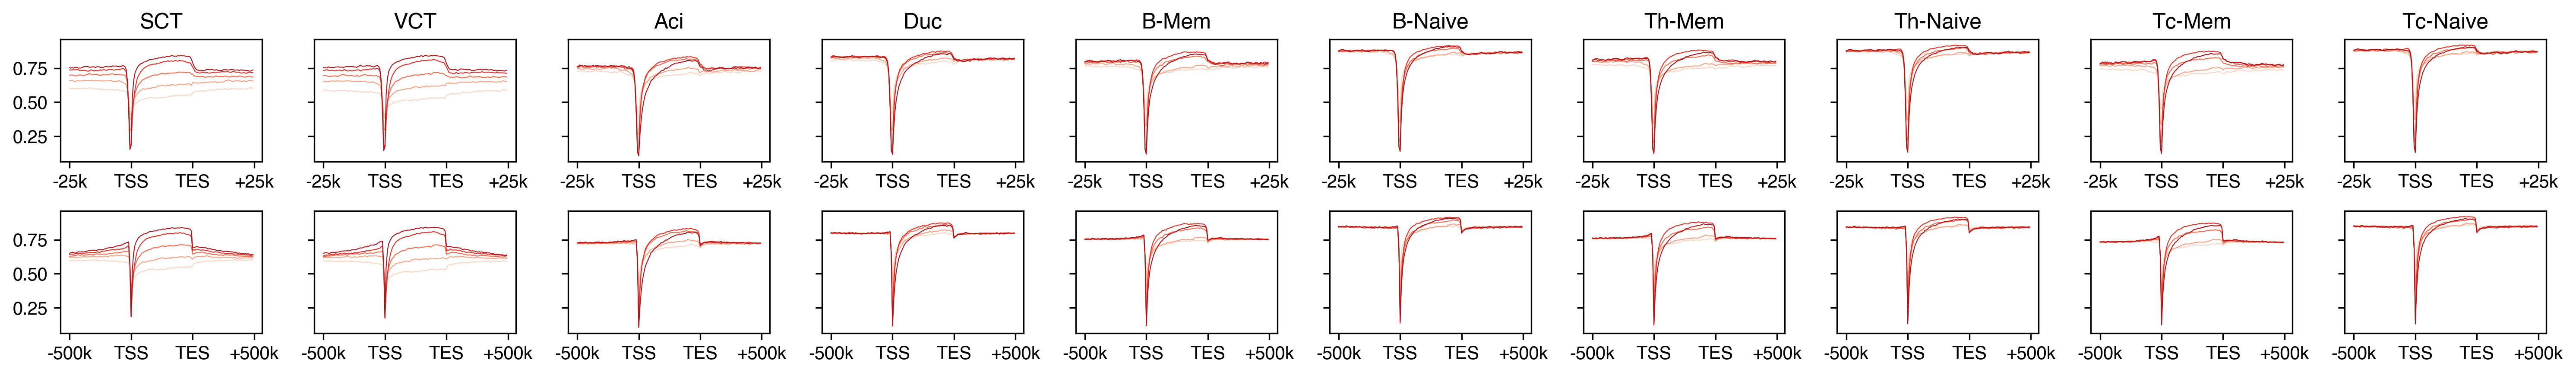

In [21]:
peak_ct = 'gene'
palette = sns.color_palette('Reds', n_colors=5)
split = 50
fig, axes = plt.subplots(2, 10, figsize=(20, 3), dpi=300, sharey=True)
for g,(group_name,study,selct) in enumerate(zip(group_name_list, study_list, selct_list)):
    expr = pd.read_hdf(f'{outdir}{group_name}/bulkexpr_{study}.hdf', key='data')
    design = pd.read_hdf(f'{outdir}{group_name}/design_{study}.hdf', key='data')
    sels = design.loc[design['celltype'].isin(selct)].sort_values('celltype').index
    expr = expr.loc[sels]
    design = design.loc[sels]
    # bw_list = selct.copy()
    expr = expr / expr.sum(axis=1).values[:, None] * 1e6
    expr = expr.groupby(design['celltype']).mean().T
    for i,(ws,w) in enumerate(zip(['25k', '500k'], ['500', '10k'])):
        for j,bw_ct in enumerate(selct):
            ax = axes[i,g*2+j]
            ratio = pd.read_hdf(f'{outdir}flank_bed/{peak_ct}.split{split}.slop{ws}b.{w}b.{bw_ct}.CGN-Merge.hdf', key='data')
            selr = (ratio.isna().sum(axis=1)<(0.2*ratio.shape[1]))
            ratio = ratio.loc[selr & ratio.index.isin(expr.index)]
            idx = np.arange(ratio.shape[1])
            exprtmp = expr.loc[ratio.index, bw_ct]
            # gene_list = [exprtmp.index[exprtmp==0]]
            # exprtmp = exprtmp[exprtmp>0]
            gene_list = []
            for _,df in exprtmp.groupby(pd.qcut(exprtmp, 5, labels=False)):
                gene_list.append(df.index)
            for k,selg in enumerate(gene_list):
                tmp = np.nanmean(ratio.loc[selg], axis=0)
                ax.plot(idx, tmp, color=palette[k], linewidth=0.5)
            if i==0:
                ax.set_title(bw_ct)
            ax.set_xticks([0, 50, 50+split, 100+split])
            ax.set_xticklabels([f'-{ws}', 'TSS', 'TES', f'+{ws}'])

fig.tight_layout()
fig.savefig(f'{outdir}mCG_geneflank_exprgroup.pdf', transparent=True)


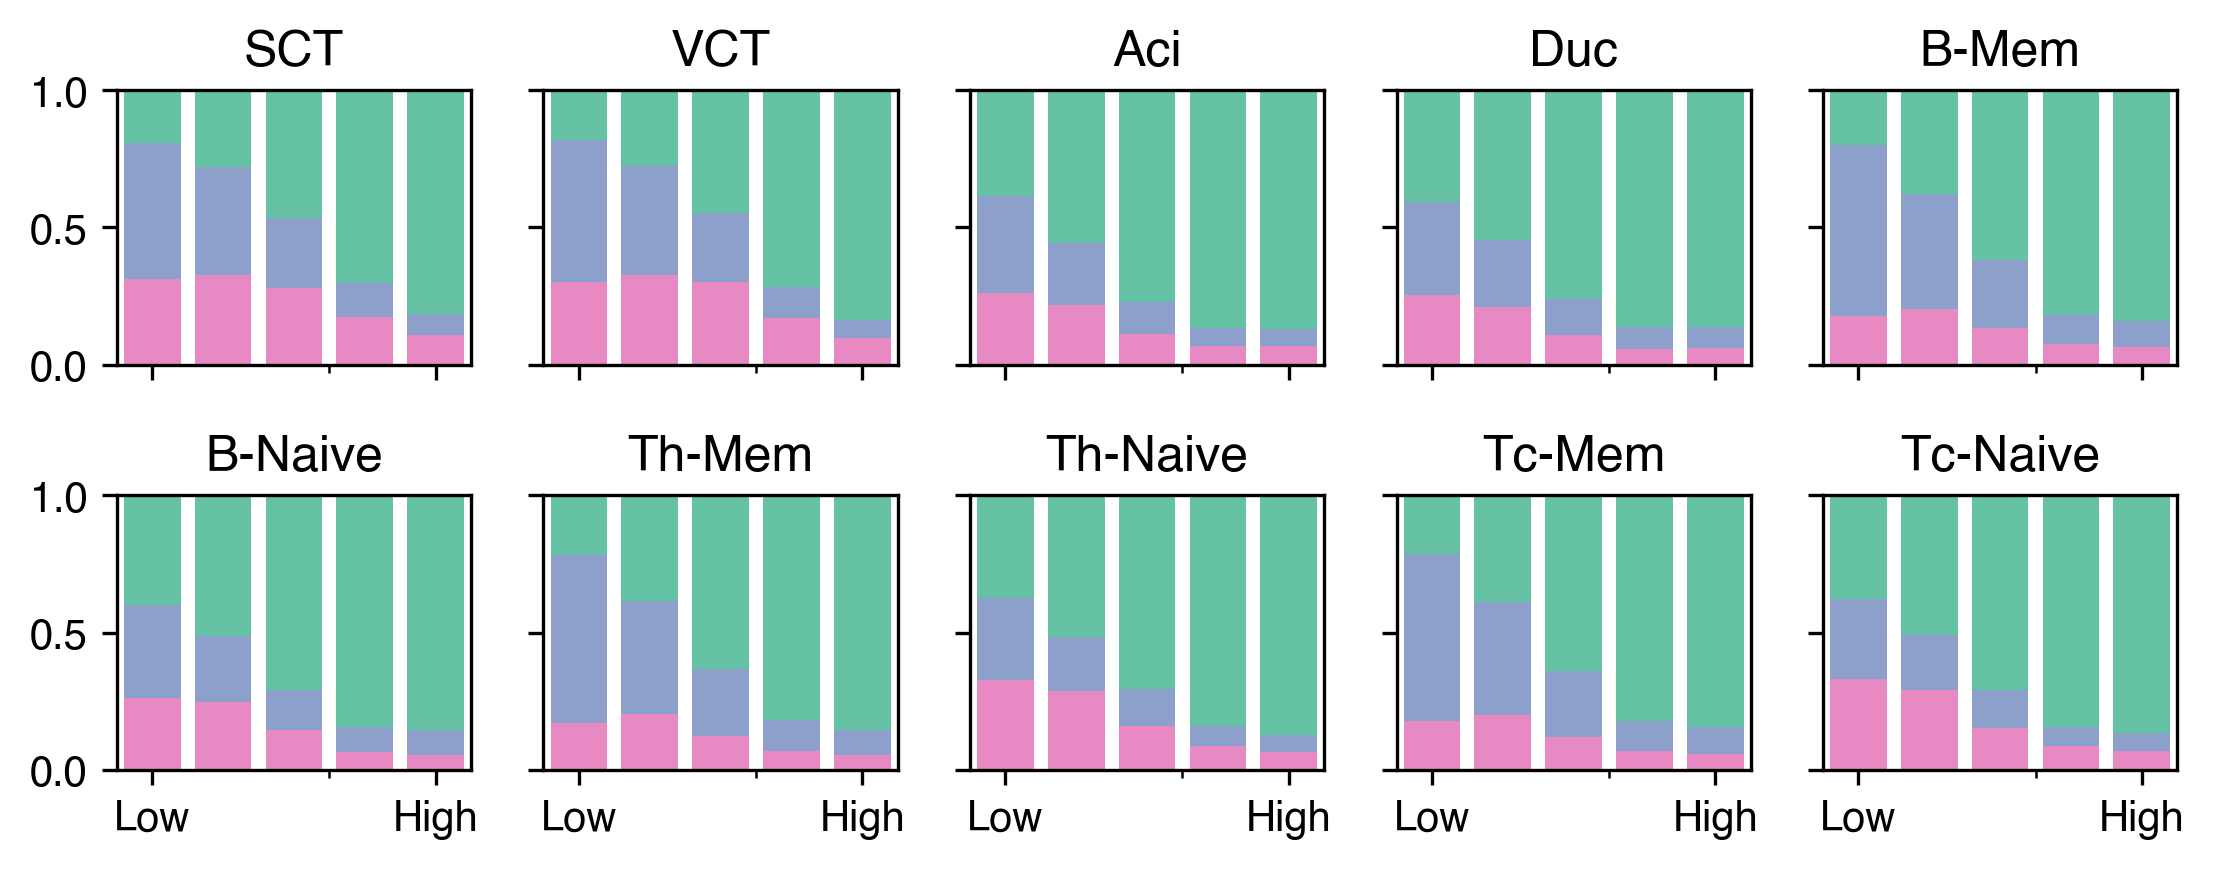

In [22]:
fig, axes = plt.subplots(2, 5, figsize=(7.5, 3), dpi=300, sharex='all', sharey='all')
for g,(group_name,study,selct,selmt) in enumerate(zip(group_name_list, study_list, selct_list, pmd_list)):
    expr = pd.read_hdf(f'{outdir}{group_name}/bulkexpr_{study}.hdf', key='data')
    design = pd.read_hdf(f'{outdir}{group_name}/design_{study}.hdf', key='data')
    sels = design.loc[design['celltype'].isin(selct)].sort_values('celltype').index
    expr = expr.loc[sels]
    design = design.loc[sels]
    # bw_list = selct.copy()
    expr = expr / expr.sum(axis=1).values[:, None] * 1e6
    expr = expr.groupby(design['celltype']).mean().T
    for j,(bw_ct,pmd_ct) in enumerate(zip(selct, selmt)):
        pmd = pd.read_csv(f'{outdir}flank_bed/tss_{pmd_ct}_3state.txt', sep='\t', index_col=3, header=None)[9]
        ax = axes.flatten()[g*2+j]
        exprtmp = expr.loc[expr.index.isin(pmd.index), bw_ct]
        # gene_list = [exprtmp.index[exprtmp==0]]
        # exprtmp = exprtmp[exprtmp>0]
        gene_list = []
        for _,df in exprtmp.groupby(pd.qcut(exprtmp, 5, labels=False)):
            gene_list.append(df.index)
        result = {}
        for k,selg in enumerate(gene_list):
            result[k] = pmd.loc[selg].value_counts()
        data = pd.concat(result, axis=1).loc[np.arange(3)]
        data = data.iloc[::-1] / data.sum(axis=0)
        data.T.plot.bar(stacked=True, color=cluster_color, ax=ax, width=0.8)
        ax.get_legend().remove()
        ax.set_title(bw_ct)
        ax.set_ylim([0,1])
        ax.set_xlim([-0.5, 4.5])
        ax.set_xticks([0, 4])
        ax.set_xticklabels(['Low', 'High'], rotation=0)

fig.tight_layout()
fig.savefig(f'{outdir}tss_3state_exprgroup_stackedbar.pdf', transparent=True)


In [23]:
group_name_list = ['Epi-TPB', 'Hema-Tmem-PBMC', 'Hema-Tnaive-PBMC']
study_list = ['Arutyunyan2023', 'Hao2021', 'Hao2021']
selct_list = [['SCT', 'VCT'], 
              ['Th-Mem', 'Tc-Mem'], 
              ['Th-Naive', 'Tc-Naive']]
pmd_list = ['c2', 'c1', 'c15']
thres_fc = [2, 1, 1]
thres_fdr = [1e-10, 1e-2, 1e-2]


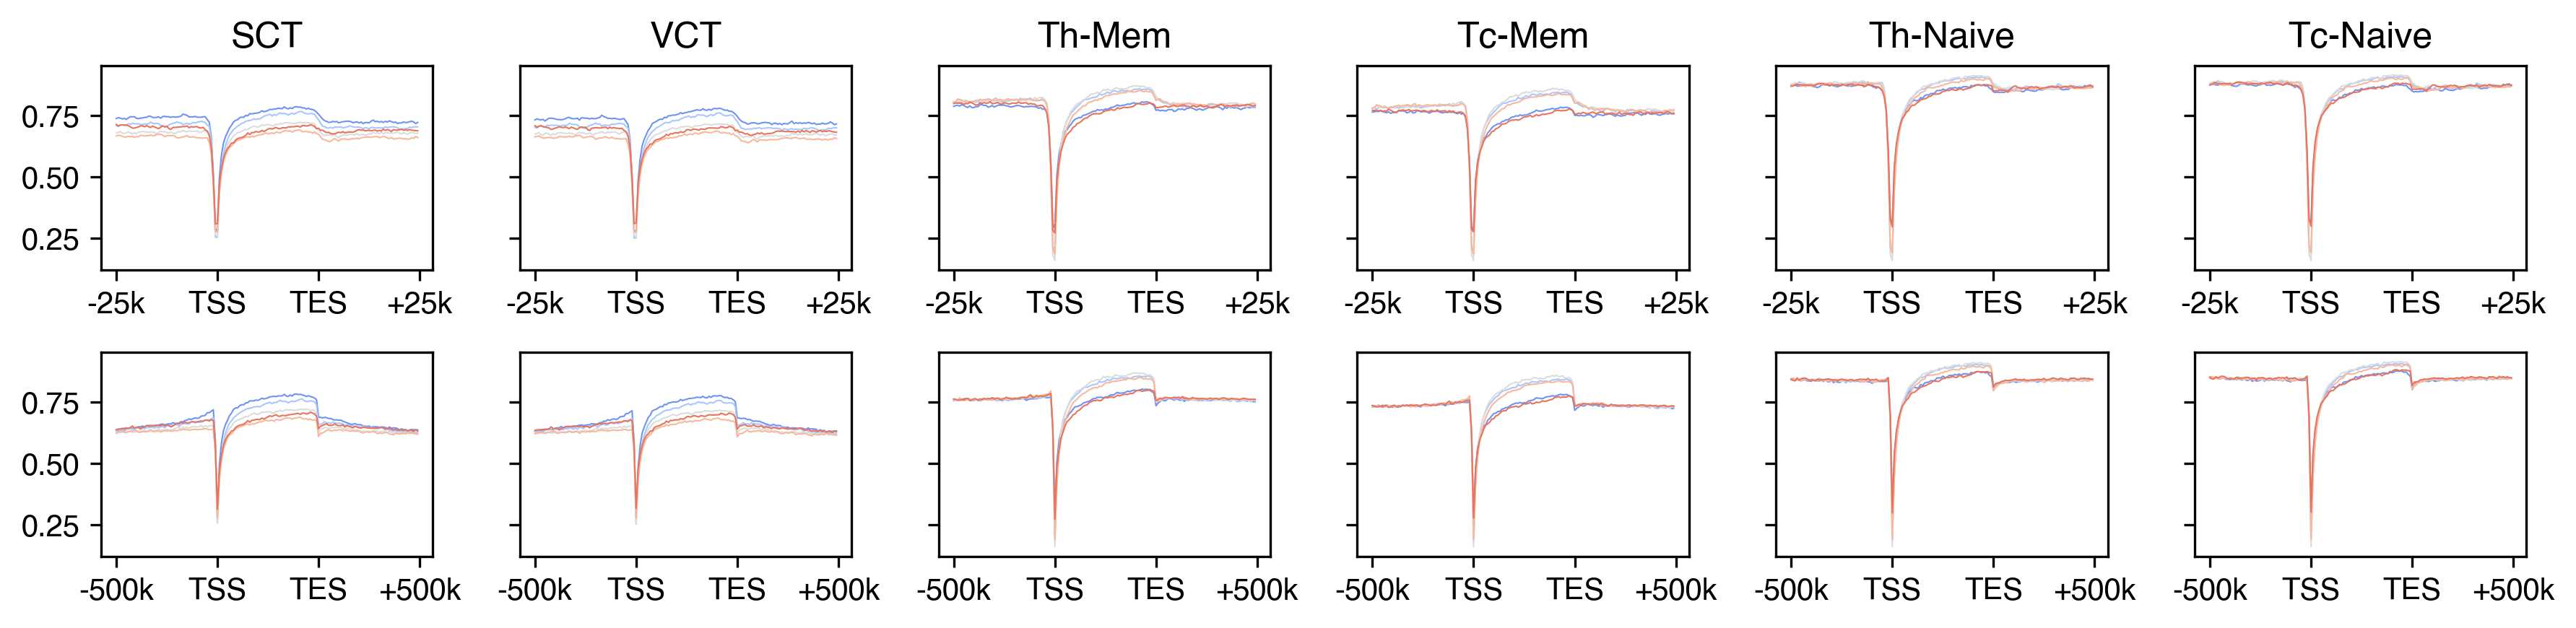

In [24]:
peak_ct = 'gene'
palette = sns.color_palette('coolwarm', n_colors=5)
split = 50
fig, axes = plt.subplots(2, 6, figsize=(12, 3), dpi=300, sharey=True)
for g,(group_name,study,selct) in enumerate(zip(group_name_list, study_list, selct_list)):
    deg_path = glob(f'{outdir}{group_name}/DEG_*_stats.hdf')[0]
    deg_stats = pd.read_hdf(deg_path, key='data')
    for i,(ws,w) in enumerate(zip(['25k', '500k'], ['500', '10k'])):
        for j,bw_ct in enumerate(selct):
            ax = axes[i,g*2+j]
            ratio = pd.read_hdf(f'{outdir}flank_bed/{peak_ct}.split{split}.slop{ws}b.{w}b.{bw_ct}.CGN-Merge.hdf', key='data')
            selr = (ratio.isna().sum(axis=1)<(0.2*ratio.shape[1]))
            ratio = ratio.loc[selr & ratio.index.isin(deg_stats.index)]
            idx = np.arange(ratio.shape[1])
            exprtmp = deg_stats.loc[ratio.index, 'log2FoldChange']
            gene_list = []
            for _,df in exprtmp.groupby(pd.qcut(exprtmp, 5, labels=False)):
                gene_list.append(df.index)
            for k,selg in enumerate(gene_list):
                tmp = np.nanmean(ratio.loc[selg], axis=0)
                ax.plot(idx, tmp, color=palette[k], linewidth=0.5)
            if i==0:
                ax.set_title(bw_ct)
            ax.set_xticks([0, 50, 50+split, 100+split])
            ax.set_xticklabels([f'-{ws}', 'TSS', 'TES', f'+{ws}'])

fig.tight_layout()
fig.savefig(f'{outdir}mCG_geneflank_fcgroup_pmdsubtype.pdf', transparent=True)


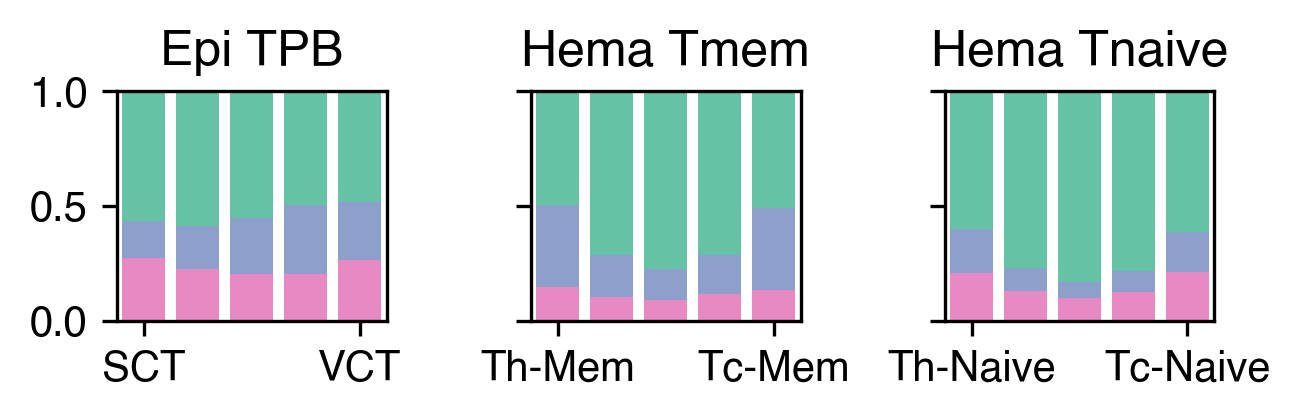

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(4.5, 1.5), dpi=300, sharey='all')
for g,(group_name,study,selct,pmd_ct) in enumerate(zip(group_name_list, study_list, selct_list, pmd_list)):
    ax = axes[g]
    pmd = pd.read_csv(f'{outdir}flank_bed/tss_{pmd_ct}_3state.txt', sep='\t', index_col=3, header=None)[9]
    deg_path = glob(f'{outdir}{group_name}/DEG_*_stats.hdf')[0]
    deg_stats = pd.read_hdf(deg_path, key='data')
    exprtmp = deg_stats.loc[deg_stats.index.isin(pmd.index), 'log2FoldChange']
    gene_list = []
    for _,df in exprtmp.groupby(pd.qcut(exprtmp, 5, labels=False)):
        gene_list.append(df.index)
    result = {}
    for k,selg in enumerate(gene_list):
        result[k] = pmd.loc[selg].value_counts()
    data = pd.concat(result, axis=1).loc[np.arange(3)]
    data = data.iloc[::-1] / data.sum(axis=0)
    data.T.plot.bar(stacked=True, color=cluster_color, ax=ax, width=0.8)
    ax.get_legend().remove()
    ax.set_title(L1_annot[pmd_ct])
    ax.set_ylim([0,1])
    ax.set_xlim([-0.5, 5-0.5])
    ax.set_xticks([0, 4])
    ax.set_xticklabels(selct, rotation=0)

fig.tight_layout()
fig.savefig(f'{outdir}tss_3state_fcgroup_pmdsubtype_stackedbar.pdf', transparent=True)


In [26]:
group_name_list = ['Epi-Exocri', 'Hema-B-PBMC', 'Hema-Th-PBMC', 'Hema-Tc-PBMC']
study_list = ['Fasolino2022', 'Hao2021', 'Hao2021', 'Hao2021']
selct_list = [['Aci', 'Duc'], 
              ['B-Mem', 'B-Naive'], 
              ['Th-Mem', 'Th-Naive'],
              ['Tc-Mem', 'Tc-Naive']]
pmd_list = [['c22', 'c30'], 
            ['c35', 'c36'], 
            ['c1', 'c15'], 
            ['c1', 'c15']]
thres_fc = [1, 1, 1, 1]
thres_fdr = [1e-5, 1e-5, 1e-5, 1e-5]
## Smaller fold change, higher expression in PMD cell type


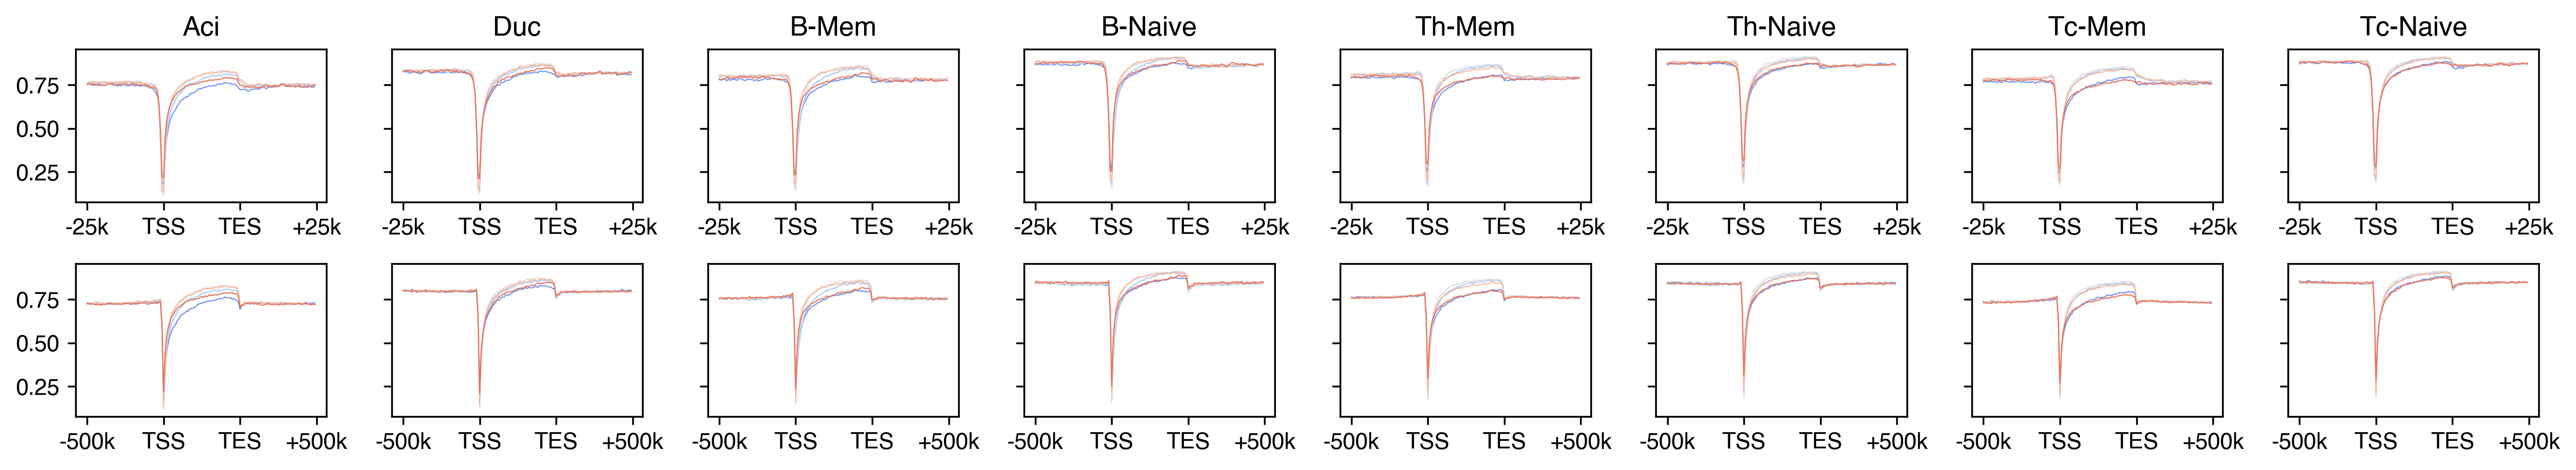

In [27]:
peak_ct = 'gene'
palette = sns.color_palette('coolwarm', n_colors=5)
split = 50
fig, axes = plt.subplots(2, 8, figsize=(16, 3), dpi=300, sharey=True)
for g,(group_name,study,selct) in enumerate(zip(group_name_list, study_list, selct_list)):
    deg_path = glob(f'{outdir}{group_name}/DEG_*_stats.hdf')[0]
    deg_stats = pd.read_hdf(deg_path, key='data')
    for i,(ws,w) in enumerate(zip(['25k', '500k'], ['500', '10k'])):
        for j,bw_ct in enumerate(selct):
            ax = axes[i,g*2+j]
            ratio = pd.read_hdf(f'{outdir}flank_bed/{peak_ct}.split{split}.slop{ws}b.{w}b.{bw_ct}.CGN-Merge.hdf', key='data')
            selr = (ratio.isna().sum(axis=1)<(0.2*ratio.shape[1]))
            ratio = ratio.loc[selr & ratio.index.isin(deg_stats.index)]
            idx = np.arange(ratio.shape[1])
            exprtmp = deg_stats.loc[ratio.index, 'log2FoldChange']
            gene_list = []
            for _,df in exprtmp.groupby(pd.qcut(exprtmp, 5, labels=False)):
                gene_list.append(df.index)
            for k,selg in enumerate(gene_list):
                tmp = np.nanmean(ratio.loc[selg], axis=0)
                ax.plot(idx, tmp, color=palette[k], linewidth=0.5)
            if i==0:
                ax.set_title(bw_ct)
            ax.set_xticks([0, 50, 50+split, 100+split])
            ax.set_xticklabels([f'-{ws}', 'TSS', 'TES', f'+{ws}'])

fig.tight_layout()
fig.savefig(f'{outdir}mCG_geneflank_fcgroup_pmdnonpmd.pdf', transparent=True)


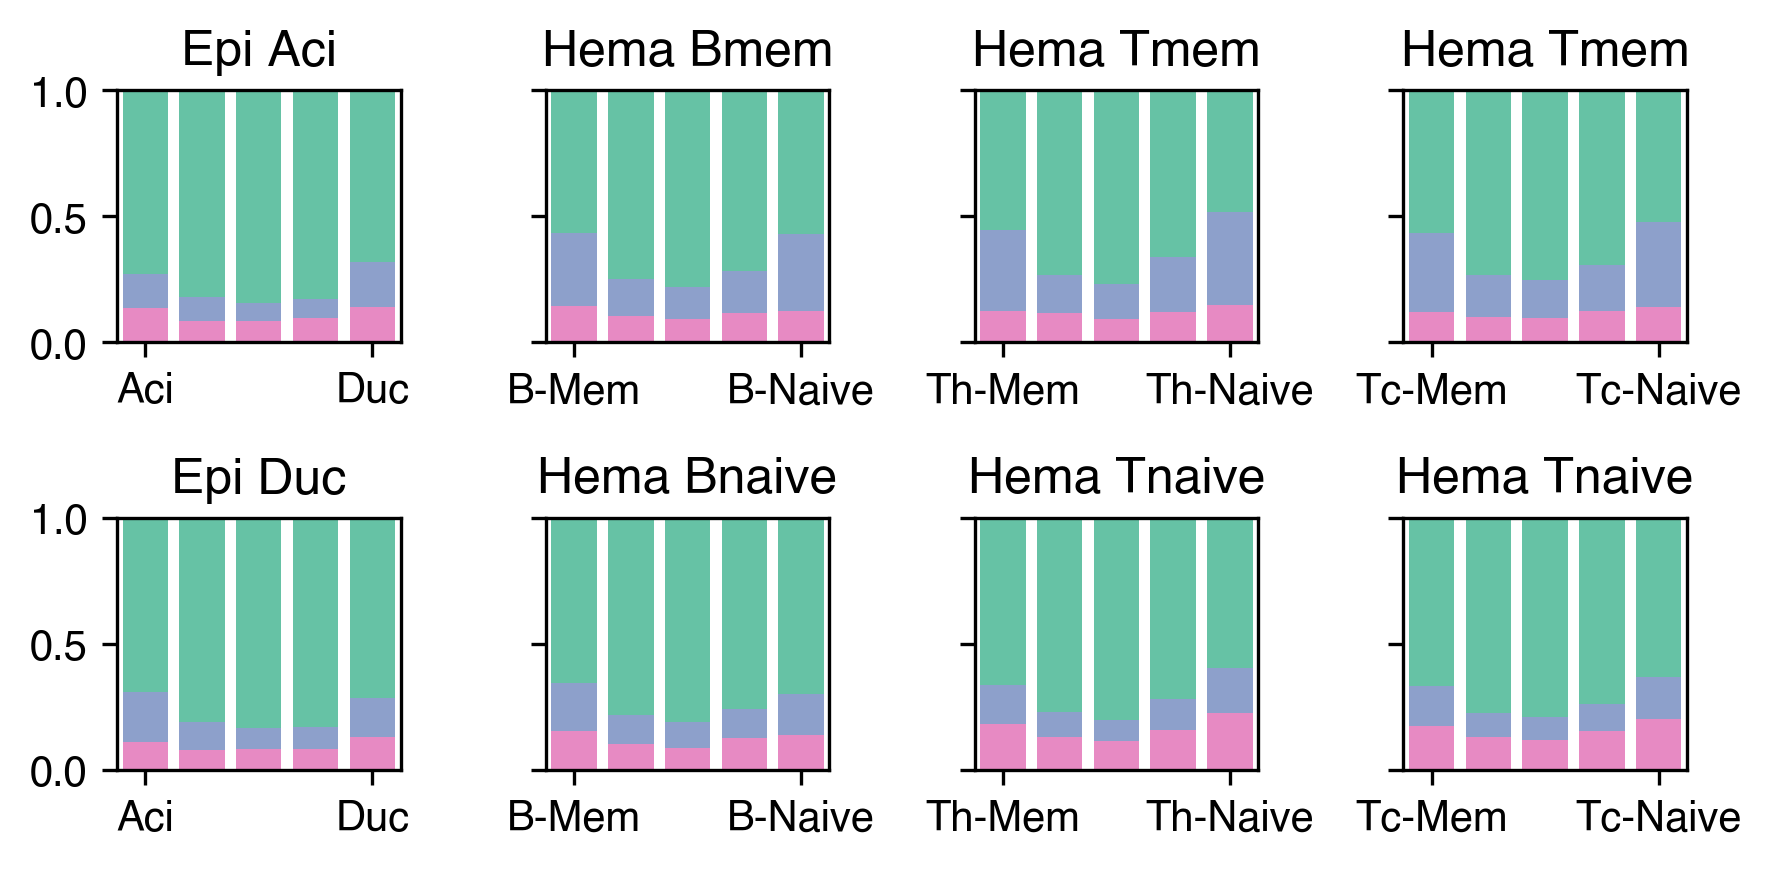

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(6, 3), dpi=300, sharey='all')
for g,(group_name,study,selct,selmt) in enumerate(zip(group_name_list, study_list, selct_list, pmd_list)):
    deg_path = glob(f'{outdir}{group_name}/DEG_*_stats.hdf')[0]
    deg_stats = pd.read_hdf(deg_path, key='data')
    for i,pmd_ct in enumerate(selmt):
        ax = axes[i,g]
        pmd = pd.read_csv(f'{outdir}flank_bed/tss_{pmd_ct}_3state.txt', sep='\t', index_col=3, header=None)[9]
        exprtmp = deg_stats.loc[deg_stats.index.isin(pmd.index), 'log2FoldChange']
        gene_list = []
        for _,df in exprtmp.groupby(pd.qcut(exprtmp, 5, labels=False)):
            gene_list.append(df.index)
        result = {}
        for k,selg in enumerate(gene_list):
            result[k] = pmd.loc[selg].value_counts()
        data = pd.concat(result, axis=1).loc[np.arange(3)]
        data = data.iloc[::-1] / data.sum(axis=0)
        data.T.plot.bar(stacked=True, color=cluster_color, ax=ax, width=0.8)
        ax.get_legend().remove()
        ax.set_title(L1_annot[pmd_ct])
        ax.set_ylim([0,1])
        ax.set_xlim([-0.5, 5-0.5])
        ax.set_xticks([0, 4])
        ax.set_xticklabels(selct, rotation=0)

fig.tight_layout()
fig.savefig(f'{outdir}tss_3state_fcgroup_pmdnonpmd_stackedbar.pdf', transparent=True)
